# IMPORTS AND SETUP

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from scipy import stats
import seaborn as sns
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [3]:
#Define years list automatically
year = [2023]

In [4]:
#Importing Data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# LOAD IN DATA

In [5]:
#Load all input files for the 2023 season
input_dfs = []
for week in range(1, 19):  # Weeks 1-18
    file_path = f'/content/drive/My Drive/NFL Big Data Bowl 2023 Input Files/input_2023_w{week:02d}.csv'
    try:
        df = pd.read_csv(file_path)
        input_dfs.append(df)
        print(f"Loaded week {week}: {len(df)} rows")
    except FileNotFoundError:
        print(f"Week {week} file not found, skipping")

#Combine all weeks
input_all = pd.concat(input_dfs, ignore_index=True)
print(f"\nTotal input rows: {len(input_all)}")

Loaded week 1: 285714 rows
Loaded week 2: 288586 rows
Loaded week 3: 297757 rows
Loaded week 4: 272475 rows
Loaded week 5: 254779 rows
Loaded week 6: 270676 rows
Loaded week 7: 233597 rows
Loaded week 8: 281011 rows
Loaded week 9: 252796 rows
Loaded week 10: 260372 rows
Loaded week 11: 243413 rows
Loaded week 12: 294940 rows
Loaded week 13: 233755 rows
Loaded week 14: 279972 rows
Loaded week 15: 281820 rows
Loaded week 16: 316417 rows
Loaded week 17: 277582 rows
Loaded week 18: 254917 rows

Total input rows: 4880579


In [6]:
#Do the same for output files
output_dfs = []
for week in range(1, 19):
    file_path = f'/content/drive/My Drive/NFL Big Data Bowl 2023 Output Files/output_2023_w{week:02d}.csv'
    try:
        df = pd.read_csv(file_path)
        output_dfs.append(df)
        print(f"Loaded week {week}: {len(df)} rows")
    except FileNotFoundError:
        print(f"Week {week} file not found, skipping")

output_all = pd.concat(output_dfs, ignore_index=True)
print(f"\nTotal output rows: {len(output_all)}")

Loaded week 1: 32088 rows
Loaded week 2: 32180 rows
Loaded week 3: 36080 rows
Loaded week 4: 30147 rows
Loaded week 5: 29319 rows
Loaded week 6: 31162 rows
Loaded week 7: 27443 rows
Loaded week 8: 33017 rows
Loaded week 9: 28291 rows
Loaded week 10: 29008 rows
Loaded week 11: 27623 rows
Loaded week 12: 32156 rows
Loaded week 13: 29568 rows
Loaded week 14: 32873 rows
Loaded week 15: 32715 rows
Loaded week 16: 36508 rows
Loaded week 17: 33076 rows
Loaded week 18: 29682 rows

Total output rows: 562936


In [7]:
#load in supp data
file_path = '/content/drive/My Drive/supplementary_data.csv'
supp_data = pd.read_csv(file_path)

/tmp/ipython-input-3531472450.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  supp_data = pd.read_csv(file_path)


In [8]:
#Create unique play id column (combination of game_id and play_id)
input_all['unique_play_id'] = input_all['game_id'].astype(str) + '_' + input_all['play_id'].astype(str)
output_all['unique_play_id'] = output_all['game_id'].astype(str) + '_' + output_all['play_id'].astype(str)
supp_data['unique_play_id'] = supp_data['game_id'].astype(str) + '_' + supp_data['play_id'].astype(str)

#Filter supp_data to only include plays that exist in both input and output
common_plays = set(input_all['unique_play_id']) & set(output_all['unique_play_id'])

supp_data_common = supp_data[supp_data['unique_play_id'].isin(common_plays)]

print(f"Original supp plays: {len(supp_data)}")
print(f"Filtered supp plays: {len(supp_data_common)}")
print(f"Common plays in input & output: {len(common_plays)}")

Original supp plays: 18009
Filtered supp plays: 14108
Common plays in input & output: 14108


# DEFENDER DISTANCE




## INPUT DATA (THROW)

In [9]:
#Use input data to find the location of players when the ball is thrown

#get the last frame from all input data of where the ball is thrown
ball_thrown_frames = input_all.groupby('unique_play_id')['frame_id'].max().reset_index()
ball_thrown_frames.columns = ['unique_play_id', 'frame_thrown']

#Get all player positions at the moment the ball is thrown
#Merge to get the frame_thrown for each play, then filter to only those frames and players to predict
positions_at_throw = input_all.merge(ball_thrown_frames, on='unique_play_id')
positions_at_throw = positions_at_throw[
    (positions_at_throw['frame_id'] == positions_at_throw['frame_thrown']) &
    (positions_at_throw['player_to_predict'] == True)
]

#Get the targeted receiver for each play at throw
targeted_receivers_throw = positions_at_throw[
    positions_at_throw['player_role'] == 'Targeted Receiver'
][['unique_play_id', 'nfl_id', 'x', 'y']]
targeted_receivers_throw.columns = ['unique_play_id', 'receiver_id', 'receiver_x_throw', 'receiver_y_throw']

#Get defenders at throw
defenders_at_throw = positions_at_throw[
    positions_at_throw['player_role'] == 'Defensive Coverage'
][['unique_play_id', 'nfl_id', 'x', 'y']]
defenders_at_throw.columns = ['unique_play_id', 'defender_throw_id', 'defender_x_throw', 'defender_y_throw']

#Calculate distance from each defender to targeted receiver at throw
defender_distances_throw = defenders_at_throw.merge(targeted_receivers_throw, on='unique_play_id')
defender_distances_throw['distance_at_throw'] = np.sqrt(
    (defender_distances_throw['defender_x_throw'] - defender_distances_throw['receiver_x_throw'])**2 +
    (defender_distances_throw['defender_y_throw'] - defender_distances_throw['receiver_y_throw'])**2
)

#Get closest defender distance at throw AND which defender it was
closest_defender_throw = defender_distances_throw.loc[
    defender_distances_throw.groupby('unique_play_id')['distance_at_throw'].idxmin()
].reset_index(drop=True)

## OUTPUT DATA (BALL LANDING)

In [10]:
#Use output data to find the location of players when the ball lands

#get the last frame from output week 1 of where each player is when the ball lands
ball_land_frames = output_all.groupby('unique_play_id')['frame_id'].max().reset_index()
ball_land_frames.columns = ['unique_play_id', 'frame_lands']

#Get all player positions at the moment the ball is thrown
#Merge to get the frame_thrown for each play, then filter to only those frames and players to predict
positions_at_landing = output_all.merge(ball_land_frames, on='unique_play_id')
positions_at_landing = positions_at_landing[
    (positions_at_landing['frame_id'] == positions_at_landing['frame_lands'])
]

#Moving onto ball landing, we need to use nfl_id to get the output information
#Get the targeted receiver nfl_id for each play from input data
targeted_receiver_ids = positions_at_throw[
    positions_at_throw['player_role'] == 'Targeted Receiver'
][['unique_play_id', 'nfl_id']]

#Get the targeted receiver positions at landing by merging with output
targeted_receivers_landing = positions_at_landing.merge(targeted_receiver_ids, on=['unique_play_id', 'nfl_id'])
targeted_receivers_landing = targeted_receivers_landing[['unique_play_id', 'nfl_id', 'x', 'y']]
targeted_receivers_landing.columns = ['unique_play_id', 'receiver_id', 'receiver_x_land', 'receiver_y_land']

#Get the defender Id's for output
defenders_at_landing_ids = positions_at_throw[
    positions_at_throw['player_role'] == 'Defensive Coverage'
][['unique_play_id', 'nfl_id']]

#Get the defender positions at landing by merging with output
defenders_at_landing = positions_at_landing.merge(defenders_at_landing_ids, on=['unique_play_id', 'nfl_id'])
defenders_at_landing = defenders_at_landing[['unique_play_id', 'nfl_id', 'x', 'y']]
defenders_at_landing.columns = ['unique_play_id', 'defender_land_id', 'defender_x_land', 'defender_y_land']

#Calculate distance from each defender to targeted receiver at ball landing

defender_distances_land = defenders_at_landing.merge(targeted_receivers_landing, on='unique_play_id')
defender_distances_land['distance_at_land'] = np.sqrt(
    (defender_distances_land['defender_x_land'] - defender_distances_land['receiver_x_land'])**2 +
    (defender_distances_land['defender_y_land'] - defender_distances_land['receiver_y_land'])**2
)

#Get closest defender distance at land AND which defender it was
closest_defender_land = defender_distances_land.loc[
    defender_distances_land.groupby('unique_play_id')['distance_at_land'].idxmin()
].reset_index(drop=True)

### Combine into one DF with Supp

In [11]:
#Combine all information with supp, defender distance at throw and land, into one row per play
#start with supp example df
combined_all_df = supp_data_common.copy()

#Merge in closest defender distance at throw
combined_all_df = combined_all_df.merge(
    closest_defender_throw[['unique_play_id', 'defender_throw_id','receiver_id','distance_at_throw']].rename(columns={'distance_at_throw': 'defender_distance_throw'}),
    on='unique_play_id',
    how='left'
)

#merge in closest defender distance at land
combined_all_df = combined_all_df.merge(
    closest_defender_land[['unique_play_id','defender_land_id', 'distance_at_land']].rename(columns={'distance_at_land': 'defender_distance_land'}),
    on='unique_play_id',
    how='left'
)

combined_all_df.head()

,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,pre_snap_home_team_win_probability,pre_snap_visitor_team_win_probability,home_team_win_probability_added,visitor_team_win_probility_added,unique_play_id,defender_throw_id,receiver_id,defender_distance_throw,defender_land_id,defender_distance_land
0,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,3461,(10:46) (Shotgun) J.Goff pass deep left to J.R...,4,...,0.834296,0.165704,-0.081149,0.081149,2023090700_3461,54600.0,44930.0,3.373559,54600.0,3.096837
1,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,461,(7:30) J.Goff pass short right to J.Reynolds t...,1,...,0.544618,0.455382,-0.029415,0.029415,2023090700_461,52546.0,44930.0,3.877422,46137.0,3.610679
2,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1940,(:09) (Shotgun) J.Goff pass incomplete deep ri...,2,...,0.771994,0.228006,0.000791,-0.000791,2023090700_1940,54486.0,38696.0,4.303592,54600.0,3.656364
3,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1711,"(:45) (No Huddle, Shotgun) P.Mahomes pass deep...",2,...,0.663187,0.336813,0.041843,-0.041843,2023090700_1711,53953.0,46213.0,3.636661,47888.0,6.655411
4,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1588,(1:54) (Shotgun) P.Mahomes pass incomplete dee...,2,...,0.615035,0.384965,0.000061,-0.000061,2023090700_1588,53953.0,46309.0,1.028251,53953.0,1.118034


## Filter to 3rd Down

In [12]:
#Filter to only 3rd down
combined_all_3rd_df = combined_all_df[combined_all_df["down"] == 3]

# GRAPHS AND ANALYSIS

## Success Rate and Defender Distance Charts

In [13]:
#Create Defensive Success and Buckets for Yards to Go

#make a copy of the dataframe to do analysis on
def_success_3rd_df = combined_all_3rd_df.copy()

#Defensive success = they did NOT get the yards to go
def_success_3rd_df["off_success"] = def_success_3rd_df["yards_gained"] >= def_success_3rd_df["yards_to_go"]
def_success_3rd_df["defensive_success"] = ~def_success_3rd_df["off_success"]

#create buckets for yards to go
def_success_3rd_df["ytg_bucket"] = pd.cut(
    def_success_3rd_df["yards_to_go"],
    bins=[0, 5, 10, 15, float("inf")],
    labels=["<5", "5--9", "10--15", ">15"]
)

#add in defender distance between throw and land
def_success_3rd_df["defender_distance_change"] = def_success_3rd_df["defender_distance_throw"] - def_success_3rd_df["defender_distance_land"]

In [14]:
#Summary table for coverage type, yards to go, and defensive success rate, and distance change

#coverage types and defensive success
coverage_bucket_def_success = (
    def_success_3rd_df
        .groupby(["team_coverage_type", "ytg_bucket"])
        .agg(
            defensive_success_rate=("defensive_success", "mean"),
            total_plays=("defensive_success", "count"),
            avg_distance_change=("defender_distance_change", "mean")
        )
        .reset_index()
        .query("total_plays > 10")
        .sort_values(["ytg_bucket", "defensive_success_rate"], ascending=False)
)

/tmp/ipython-input-2741138732.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["team_coverage_type", "ytg_bucket"])


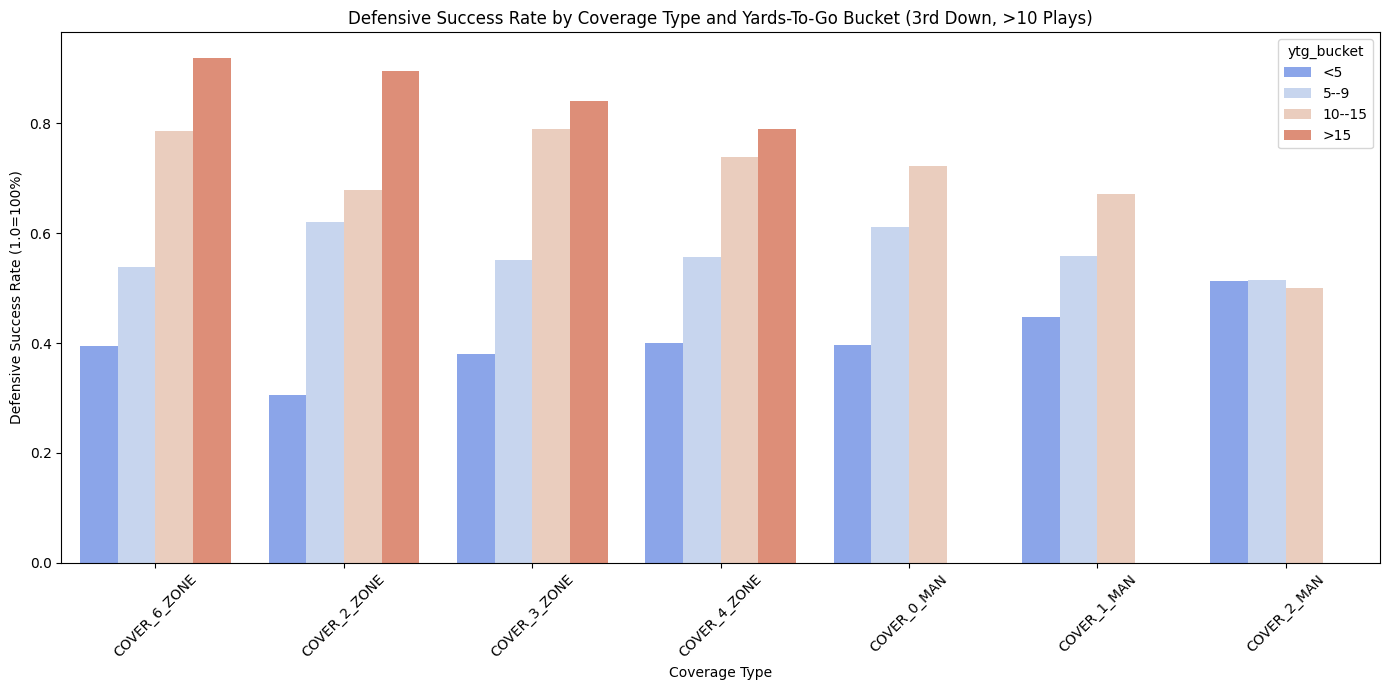

In [15]:
#Bar chart for coverage types vs defensive success, with yards to go buckets
plt.figure(figsize=(14,7))

sns.barplot(
    data=coverage_bucket_def_success,
    x="team_coverage_type",
    y="defensive_success_rate",
    hue="ytg_bucket",
    palette="coolwarm"
)

plt.title("Defensive Success Rate by Coverage Type and Yards-To-Go Bucket (3rd Down, >10 Plays)")
plt.xlabel("Coverage Type")
plt.ylabel("Defensive Success Rate (1.0=100%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3363475039.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["team_coverage_type", "ytg_bucket"])


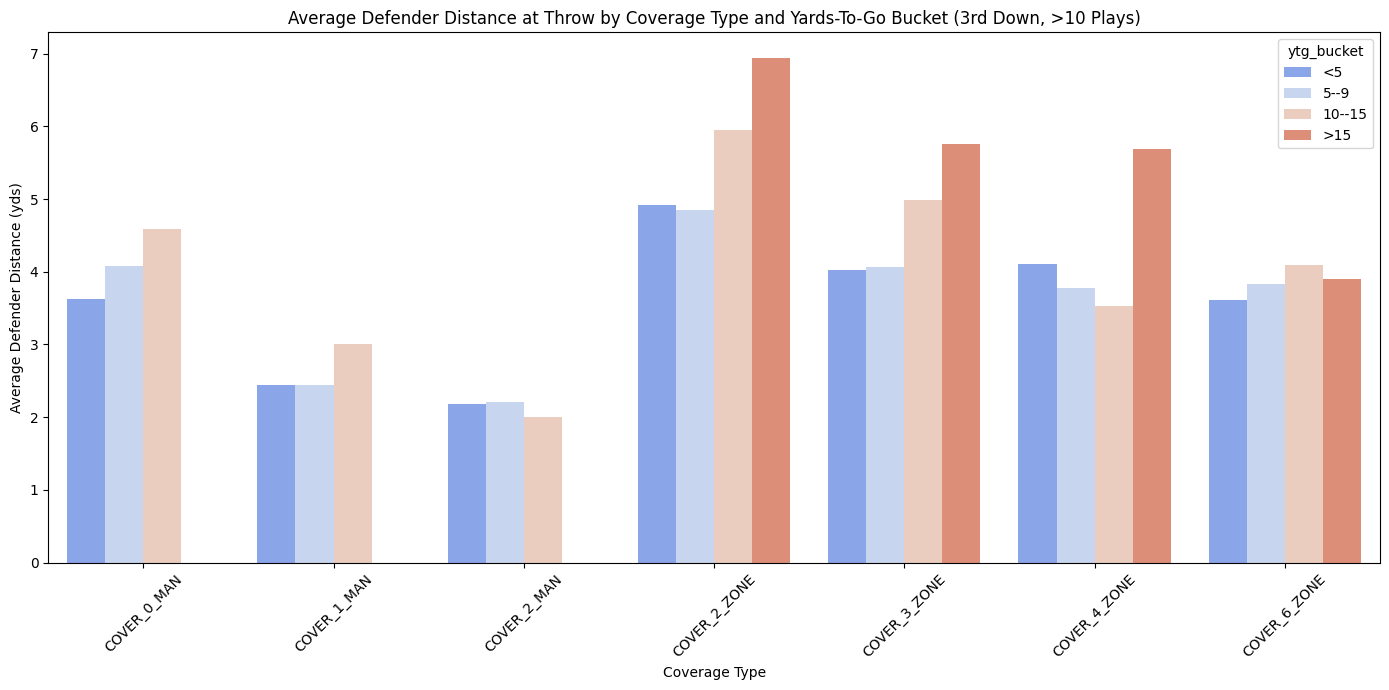

In [16]:
#Bar chart for coverage types vs average defender distance when the ball is thrown, with yards to go buckets

#aggregate average defender distance by coverage and YTG bucket
coverage_bucket_distance = (
    def_success_3rd_df
        .groupby(["team_coverage_type", "ytg_bucket"])
        .agg(
            avg_defender_distance=("defender_distance_throw", "mean"),
            total_plays=("defender_distance_throw", "count")
        )
        .reset_index()
        .query("total_plays > 10")
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=coverage_bucket_distance,
    x="team_coverage_type",
    y="avg_defender_distance",
    hue="ytg_bucket",
    palette="coolwarm"
)

plt.title("Average Defender Distance at Throw by Coverage Type and Yards-To-Go Bucket (3rd Down, >10 Plays)")
plt.xlabel("Coverage Type")
plt.ylabel("Average Defender Distance (yds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1437541355.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["team_coverage_type", "ytg_bucket"])


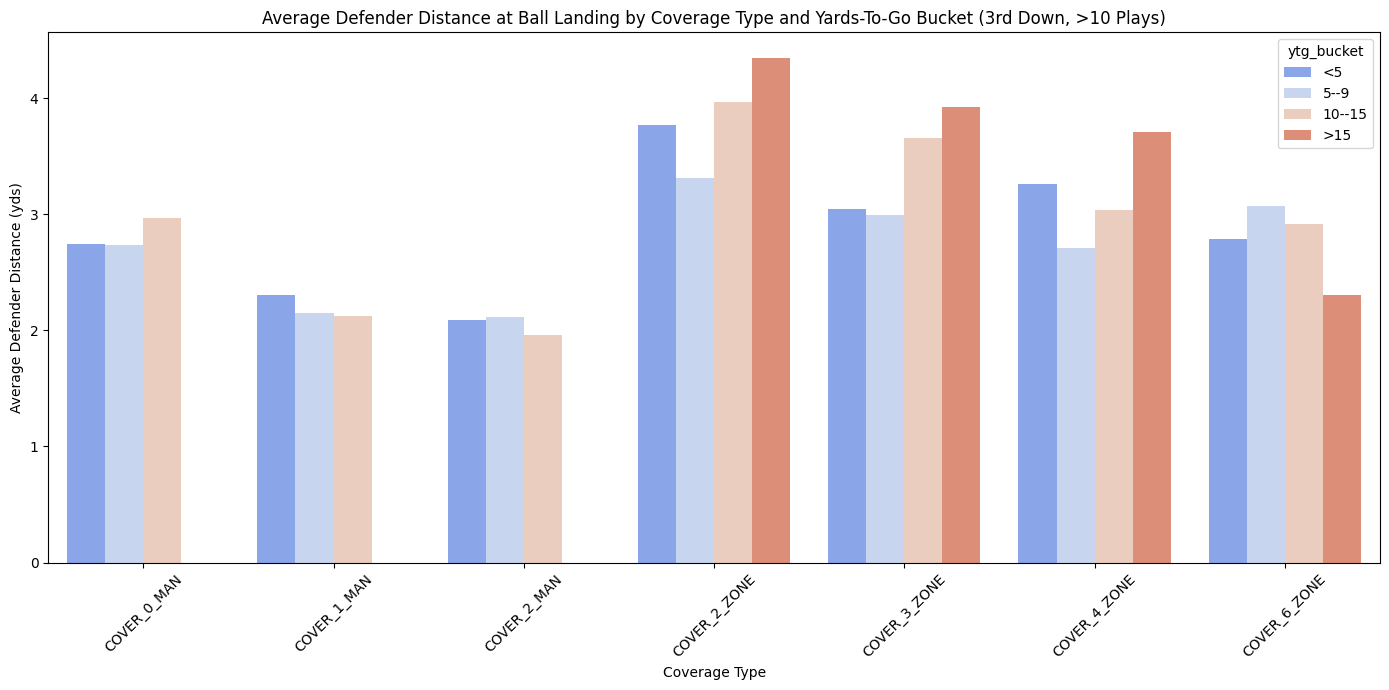

In [17]:
#Bar chart for coverage types vs average defender distance when the ball lands, with yards to go buckets

#aggregate average defender distance by coverage and YTG bucket
coverage_bucket_distance = (
    def_success_3rd_df
        .groupby(["team_coverage_type", "ytg_bucket"])
        .agg(
            avg_defender_distance=("defender_distance_land", "mean"),
            total_plays=("defender_distance_land", "count")
        )
        .reset_index()
        .query("total_plays > 10")
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=coverage_bucket_distance,
    x="team_coverage_type",
    y="avg_defender_distance",
    hue="ytg_bucket",
    palette="coolwarm"
)

plt.title("Average Defender Distance at Ball Landing by Coverage Type and Yards-To-Go Bucket (3rd Down, >10 Plays)")
plt.xlabel("Coverage Type")
plt.ylabel("Average Defender Distance (yds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Trendline Statistics:
Slope: 0.2786
R-squared: 0.2095
Correlation (R): 0.4577
P-value: 0.0084


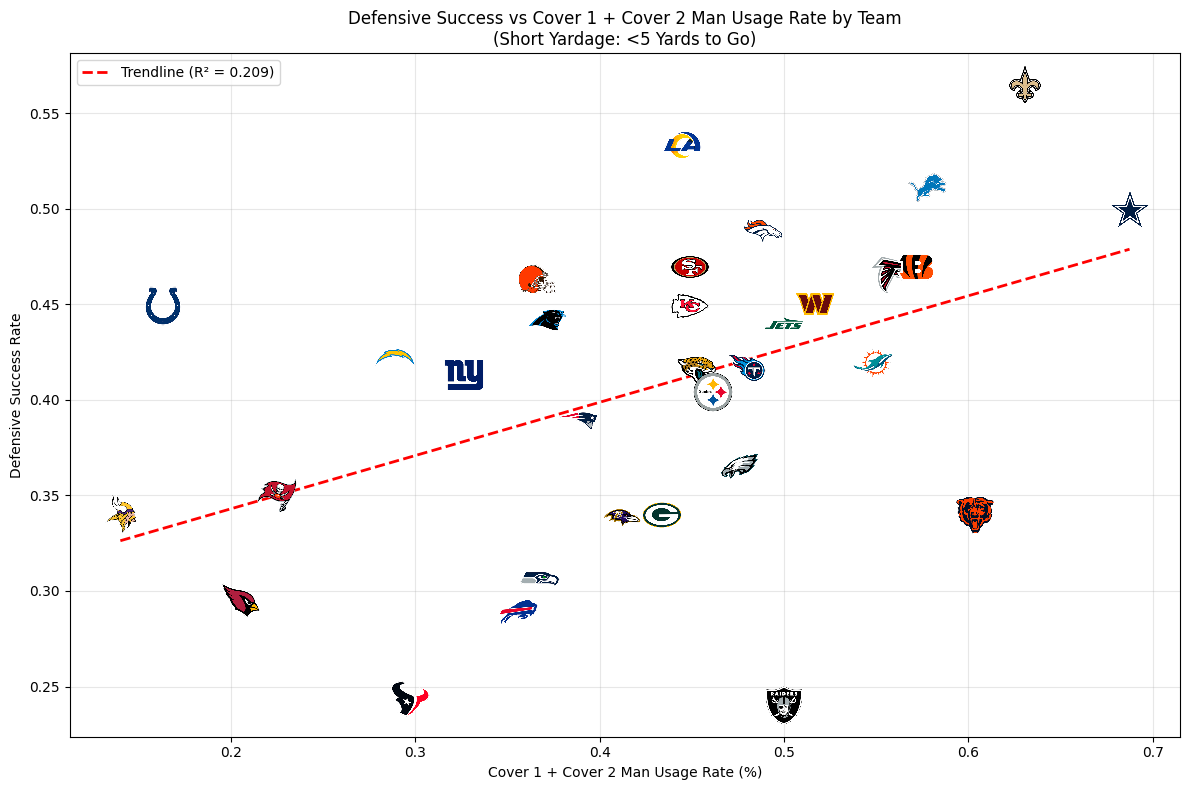


Top 5 Teams by Cover 1 + Cover 2 Man Usage:
defensive_team  cover_pct  defensive_success_rate
           DAL   0.687500                0.500000
            NO   0.630435                0.565217
           CHI   0.603774                0.339623
           DET   0.577778                0.511111
           CIN   0.571429                0.469388

Bottom 5 Teams by Cover 1 + Cover 2 Man Usage:
defensive_team  cover_pct  defensive_success_rate
           MIN   0.140000                0.340000
           IND   0.163265                0.448980
           ARI   0.204545                0.295455
            TB   0.225000                0.350000
           LAC   0.288889                0.422222


In [19]:
#Cover 1 and 2 Man Usage
#load in logos
LOGO_DIR = "/content/drive/MyDrive/logos"

#helper function to load logo by team name (must match your PNG filenames)
def get_logo(team_name, zoom=0.12):
    file_path = os.path.join(LOGO_DIR, f"{team_name}.png")
    img = Image.open(file_path)
    return OffsetImage(img, zoom=zoom)

#create metrics
#filter for short yardage plays
def_success_short = def_success_3rd_df[def_success_3rd_df["ytg_bucket"] == "<5"]

#calculate Cover 1 + Cover 2 Man usage rate and defensive success by team
team_cover_analysis = (
    def_success_short.groupby("defensive_team")
    .agg(
        total_plays=("defensive_success", "count"),
        cover_plays=("team_coverage_type", lambda x: (
            (x == "COVER_1_MAN") | (x == "COVER_2_MAN")
        ).sum()),
        defensive_success_rate=("defensive_success", "mean")
    )
    .reset_index()
)

#calculate Cover 1 + Cover 2 Man usage percentage
team_cover_analysis["cover_pct"] = (
    team_cover_analysis["cover_plays"] / team_cover_analysis["total_plays"]
)

#filter for teams with meaningful sample size
team_cover_analysis = team_cover_analysis[team_cover_analysis["total_plays"] > 10]

#create plot
plt.figure(figsize=(12, 8))

#scatter points invisible — logos will be on top
plt.scatter(
    team_cover_analysis["cover_pct"],
    team_cover_analysis["defensive_success_rate"],
    s=0,    # <-- hide points
)

#add the logos
for idx, row in team_cover_analysis.iterrows():
    x = row["cover_pct"]
    y = row["defensive_success_rate"]
    team = row["defensive_team"]

    ab = AnnotationBbox(get_logo(team, zoom=0.12), (x, y), frameon=False)
    plt.gca().add_artist(ab)

#trendline
x = team_cover_analysis["cover_pct"]
y = team_cover_analysis["defensive_success_rate"]

if x.std() > 0:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r--', linewidth=2,
             label=f'Trendline (R² = {r_value**2:.3f})')

    print(f"\nTrendline Statistics:")
    print(f"Slope: {slope:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"Correlation (R): {r_value:.4f}")
    print(f"P-value: {p_value:.4f}")
else:
    print("\nInsufficient variation in Cover 1 + Cover 2 Man usage to calculate trendline")


#labels
plt.xlabel("Cover 1 + Cover 2 Man Usage Rate (%)")
plt.ylabel("Defensive Success Rate")
plt.title("Defensive Success vs Cover 1 + Cover 2 Man Usage Rate by Team\n(Short Yardage: <5 Yards to Go)")
if x.std() > 0:
    plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#summary tables
print("\nTop 5 Teams by Cover 1 + Cover 2 Man Usage:")
print(team_cover_analysis.nlargest(5, "cover_pct")[["defensive_team", "cover_pct", "defensive_success_rate"]].to_string(index=False))

print("\nBottom 5 Teams by Cover 1 + Cover 2 Man Usage:")
print(team_cover_analysis.nsmallest(5, "cover_pct")[["defensive_team", "cover_pct", "defensive_success_rate"]].to_string(index=False))

## Bootstrapped Bar Graphs

/tmp/ipython-input-4144990214.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["team_coverage_type", "ytg_bucket"])


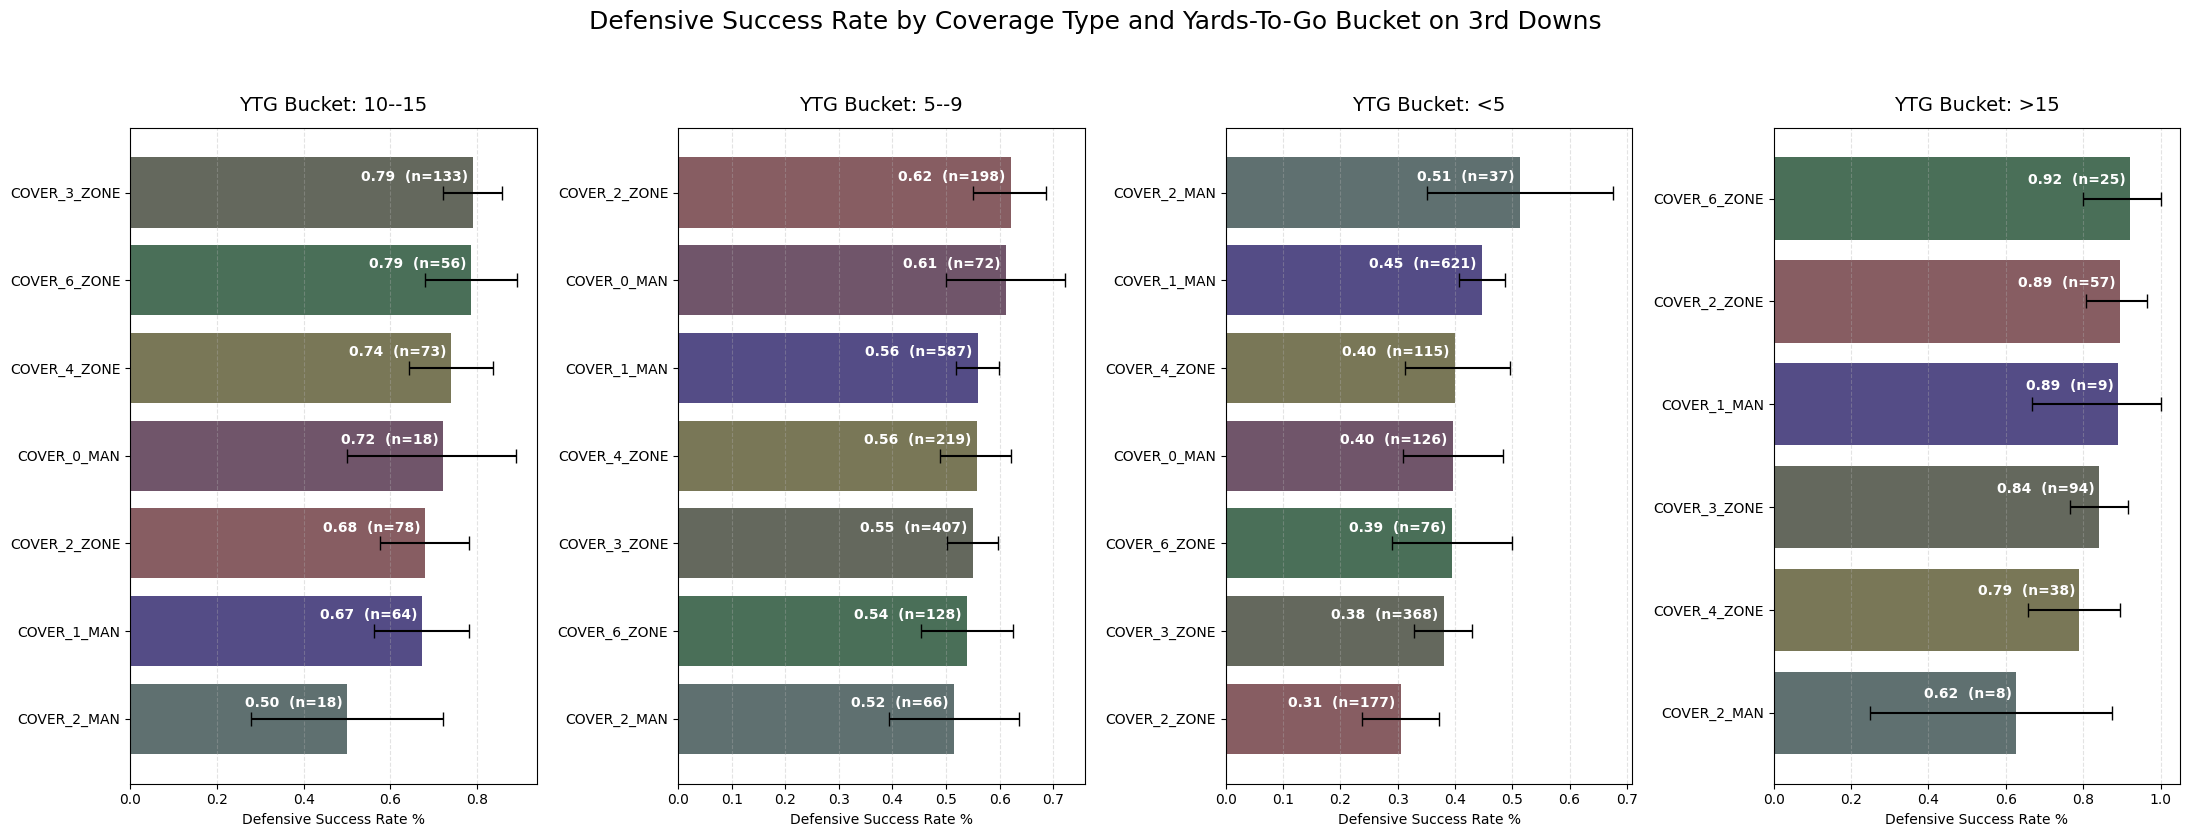

In [20]:
#Bar charts for coverage types vs defensive success, with yards to go buckets as seperate charts

#iterations for bootstrapping
BOOTSTRAP_ITER = 2000

#Group by coverage yards to go buckets
coverage_summary = (
    def_success_3rd_df
        .groupby(["team_coverage_type", "ytg_bucket"])
        .agg(
            success_rate=("defensive_success", "mean"),
            plays=("defensive_success", "count"),
            values=("defensive_success", lambda x: list(x.dropna()))
        )
        .reset_index()
        .query("plays > 5")
)

#bootstrap CI function
def bootstrap_ci(data, n_iter=BOOTSTRAP_ITER):
    if not isinstance(data, (list, np.ndarray)) or len(data) == 0:
        return (np.nan, np.nan)
    samples = [
        np.mean(np.random.choice(data, size=len(data), replace=True))
        for _ in range(n_iter)
    ]
    return (np.percentile(samples, 2.5),
            np.percentile(samples, 97.5))

# Compute CI columns
coverage_summary["ci_low"]  = coverage_summary["values"].apply(lambda x: bootstrap_ci(x)[0])
coverage_summary["ci_high"] = coverage_summary["values"].apply(lambda x: bootstrap_ci(x)[1])

# ------------------------
# Step 3: Color map for coverage types
# ------------------------
def random_nfl_color():
    return (
        random.random() * 0.3 + 0.2,
        random.random() * 0.3 + 0.2,
        random.random() * 0.3 + 0.2,
    )

unique_coverages = sorted(coverage_summary["team_coverage_type"].unique())
color_map = {c: random_nfl_color() for c in unique_coverages}

# ------------------------
# Step 4: Plotting by YTG bucket
# ------------------------
ytg_buckets = sorted(coverage_summary["ytg_bucket"].unique())
fig, axes = plt.subplots(1, len(ytg_buckets), figsize=(22, 8), sharey=False)

if len(ytg_buckets) == 1:
    axes = [axes]

for ax, bucket in zip(axes, ytg_buckets):

    df = coverage_summary[coverage_summary["ytg_bucket"] == bucket].copy()
    df = df.sort_values("success_rate", ascending=True)

    y_positions = np.arange(len(df))

    bars = ax.barh(
        y_positions,
        df["success_rate"],
        xerr=[df["success_rate"] - df["ci_low"], df["ci_high"] - df["success_rate"]],
        capsize=5,
        color=[color_map[c] for c in df["team_coverage_type"]],
        alpha=0.9
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df["team_coverage_type"], fontsize=10)

    ax.set_title(f"YTG Bucket: {bucket}", fontsize=14, pad=12)
    ax.set_xlabel("Defensive Success Rate %")
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    # ------------------------
    # Annotation placement
    # ------------------------
    for i, (bar, rate, plays) in enumerate(zip(bars, df["success_rate"], df["plays"])):
        bar_width = bar.get_width()
        label_text = f"{rate:.2f}  (n={plays})"

        if bar_width > 0.22:
            ax.text(
                bar_width - 0.01,
                i + .18,
                label_text,
                va="center",
                ha="right",
                color="white",
                fontsize=10,
                fontweight='bold'
            )
        else:
            ax.text(
                bar_width + 0.01,
                i,
                label_text,
                va="center",
                ha="left",
                fontsize=9
            )

plt.suptitle(
    "Defensive Success Rate by Coverage Type and Yards-To-Go Bucket on 3rd Downs",
    fontsize=18,
    y=1.04
)

plt.tight_layout()
plt.show()
